# Budget Analysis V.3

**Note**: Expense might not be too accurate due to *reimbursements*. 

# Package Import

In [1]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine

import emoji
import re

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from datetime import date, time, timedelta, datetime
from dateutil.relativedelta import relativedelta

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# Database Connection

In [3]:
try:
    conn = create_engine('sqlite:///money_android.sqlite')
    try:
        test_con = '''select name as tables from sqlite_master where type="table"'''
        display(pd.read_sql(test_con, conn))
        del test_con
    except Exception as e:
        print(f'Error Retrieving data: {e}')
except Exception as e:
    print(f'Database Connection fail: {e}')

,tables
0,android_metadata
1,MESSAGEMACRO2
2,sqlite_sequence
3,INOUTCOME
4,ASSETS
5,ZCATEGORY
6,ZETC
7,SMS_RAW_READ
8,REPEATTRANSACTION
9,FAVTRANSACTION


# Data Import

In [5]:
bdgt_tbl = pd.read_sql('select * from INOUTCOME', conn)
cat_tbl = pd.read_sql('select * from ZCATEGORY', conn)
asset_tbl = pd.read_sql('select * from ASSETS', conn)

display(bdgt_tbl, cat_tbl, asset_tbl)

,AID,uid,assetUid,CARDDIVIDMONTH,ctgUid,toAssetUid,ZCONTENT,ZDATE,WDATE,wtime,paid,DO_TYPE,ZMONEY,txUidTrans,ZDATA,SMS_RDATE,IN_ZMONEY,ASSET_NIC,CATEGORY_NAME,cardDivideUid,CARD_DIVIDE_MONTH_STR,MARK,txUidFee,SMS_ORIGIN,SMS_PARSE_CONTENT,IS_DEL,UTIME,currencyUid,AMOUNT_ACCOUNT,lat,lng,gstd,isSynced,syncTime,syncVersion
0,1,c8638ef1-5755-4492-87e0-fc2cc234791e,11,0,9,,,1726617607841,2024-09-18,None,None,1,1475.23,,,,25.0,None,None,,,0,None,None,None,0,1736642830928,PHP_USD,25.00,None,None,None,0,None,0
1,2,845207f5-c8ae-4116-8e62-20ece9ca2c2f,11,0,6,,Don Lemon 🍋,1726632007841,2024-09-18,None,None,1,1711.26,,,,29.0,None,None,,,0,None,None,None,0,1736642830928,PHP_USD,29.00,None,None,None,0,None,0
2,3,011c5f04-6c3e-4bce-9e63-e303c4ac570a,2,0,6,,Samgyup,1726380441057,2024-09-15,None,None,1,116660.8,,,,1977.0,None,None,,,0,None,None,None,0,1736642830928,PHP_USD,1977.00,None,None,None,0,None,0
3,4,1d502cea-0868-4243-a6e2-c4ec06dc0717,11,0,6,,Samgyup,1726227055993,2024-09-13,None,None,1,35346.39,,,,599.0,None,None,,,0,None,None,None,0,1736642830928,PHP_USD,599.00,None,None,None,0,None,0
4,5,88eb9171-fd63-4c0e-95b9-c5d149e2e01c,1,0,17,,Udemy + Corn Kape,1726231445059,2024-09-13,None,None,1,76711.71,,,,1300.0,None,None,,,0,None,None,None,0,1736642830928,PHP_USD,1300.00,None,None,None,0,None,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049,1059,4c17dc8a-9ef3-42e1-97b3-7945d25aed5c,1,0,,1,Gcash,1752014829145,2025-07-09,None,None,3,2500.0,bf6c10e5-8008-49ca-83d2-7a384272da5c,,,2500.0,None,None,,,0,ef0130d1-c735-4888-854a-f4ac6646cbc6,None,None,0,1752101289467,PHP_PHP,42.37,None,None,None,0,None,0
1050,1060,1d6fe22f-b3ca-4b92-9a9b-c0a5ff9319a7,1,0,,1,Gcash,1752014829145,2025-07-09,None,None,4,2500.0,bf6c10e5-8008-49ca-83d2-7a384272da5c,,,2500.0,None,None,,,0,ef0130d1-c735-4888-854a-f4ac6646cbc6,None,None,0,1752101289470,PHP_PHP,42.37,None,None,None,0,None,0
1051,1061,eada5f7d-fdf7-4fd6-aa06-db7c701521da,1,0,a732691e-9cb2-47f1-9143-0be4f1039c89,,Add sa Bill,1752014829145,2025-07-09,None,None,1,1000.0,,Withdraw 3800\nSend. 2500\n ...,,1000.0,None,None,,,0,None,None,None,0,1752101921560,PHP_PHP,16.95,None,None,None,0,None,0
1052,1062,79480c54-e934-4bb0-a89c-c9d4d0ee6ef4,1,0,,11,Withdraw,1752014829145,2025-07-09,None,None,3,1500.0,5fb30898-b16f-4301-afc9-06cb6b2414dc,Withdraw 3800\nSend. 2500\n ...,,1500.0,None,None,,,0,None,None,None,0,1752101980818,PHP_PHP,25.42,None,None,None,0,None,0


,ID,C_IS_DEL,C_UTIME,uid,NAME,ORDERSEQ,TYPE,STATUS,pUid,isSynced,syncTime,syncVersion
0,1,None,1726638920691,1,🤑 Allowance,1,0,0,0,0,None,0
1,2,None,1726638920691,2,💰 Salary,2,0,0,0,0,None,0
2,3,None,1726638920693,3,💵 Petty cash,3,0,0,0,0,None,0
3,4,None,1726638920694,4,🏅 Bonus,4,0,0,0,0,None,0
4,5,None,1726638920695,5,Other,5,0,0,0,0,None,0
...,...,...,...,...,...,...,...,...,...,...,...,...
64,65,None,1739582285466,e23aa8f6-06d9-4b33-a1c5-e696faa16224,Snacks 🍟,5,1,2,6,0,None,0
65,66,None,1739106862285,7b0c7dac-639f-41b4-a7f5-4e34a654a1fc,Internet 💻,66,1,2,4076de27-f668-41e8-ac5c-dcc0c69b7cae,0,None,0
66,67,None,1739582090198,42d4ac1f-866b-4e15-820b-6a7b762ec602,Incentives,67,0,0,,0,None,0
67,68,None,1739582285460,8087c509-180d-4b4a-ac10-468a0f868662,Breakfast,0,1,2,6,0,None,0


,ID,CARD_DAY_FIN,CARD_DAY_PAY,NIC_NAME,ORDERSEQ,ZDATA,ZDATA1,ZDATA2,IS_TRANS_EXPENSE,IS_CARD_AUTO_PAY,APP_PACKAGE,APP_NAME,SMS_TEL,SMS_STRING,A_UTIME,CARD_USAGE_HURDLE_TYPE,CARD_USAGE_HURDLE_START_DATE,CARD_USAGE_HURDLE_AMOUNT,uid,currencyUid,cardAssetUid,groupUid,isSynced,syncTime,syncVersion
0,1,1,1,Cash,1,,,0,0,0,None,None,,,1736642830921,1,None,0.0,11,PHP_USD,,11,0,None,None
1,2,1,1,Accounts,2,,,0,0,0,None,None,,,1736642830924,1,None,0.0,1,PHP_USD,,1,0,None,None
2,3,1,1,Card,3,,,0,0,0,None,None,,,1736642830925,1,None,0.0,2,PHP_USD,1,2,0,None,None


# Data Normalization

## Data Mapping

In [11]:
cat_dict = dict(zip(cat_tbl['uid'], cat_tbl['NAME']))
asset_dict = dict(zip(asset_tbl['uid'],asset_tbl['NIC_NAME']))
do_dict = {'0':'Income', '1':'Expense', '3':'Transfer From', '4':'Transfer To'}

bdgt_tbl['Category'] = bdgt_tbl['ctgUid'].map(cat_dict)
bdgt_tbl['Assets'] = bdgt_tbl['assetUid'].map(asset_dict)
bdgt_tbl['Fin_Transaction'] = bdgt_tbl['DO_TYPE'].map(do_dict)

final_bdg = bdgt_tbl[['uid', 'Fin_Transaction', 'Assets', 'Category', 'ZCONTENT', 'WDATE', 'IN_ZMONEY']]
final_bdg.rename(columns= {'ZCONTENT':'Notes', 'WDATE':'Dates', 'IN_ZMONEY':'Amount'}, inplace=True)

In [13]:
final_bdg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1054 entries, 0 to 1053
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   uid              1054 non-null   object
 1   Fin_Transaction  1054 non-null   object
 2   Assets           1054 non-null   object
 3   Category         862 non-null    object
 4   Notes            1054 non-null   object
 5   Dates            1054 non-null   object
 6   Amount           1054 non-null   object
dtypes: object(7)
memory usage: 57.8+ KB


In [15]:
final_bdg

,uid,Fin_Transaction,Assets,Category,Notes,Dates,Amount
0,c8638ef1-5755-4492-87e0-fc2cc234791e,Expense,Cash,🚖 Transport,,2024-09-18,25.0
1,845207f5-c8ae-4116-8e62-20ece9ca2c2f,Expense,Cash,🍜 Food,Don Lemon 🍋,2024-09-18,29.0
2,011c5f04-6c3e-4bce-9e63-e303c4ac570a,Expense,Card,🍜 Food,Samgyup,2024-09-15,1977.0
3,1d502cea-0868-4243-a6e2-c4ec06dc0717,Expense,Cash,🍜 Food,Samgyup,2024-09-13,599.0
4,88eb9171-fd63-4c0e-95b9-c5d149e2e01c,Expense,Accounts,Other,Udemy + Corn Kape,2024-09-13,1300.0
...,...,...,...,...,...,...,...
1049,4c17dc8a-9ef3-42e1-97b3-7945d25aed5c,Transfer From,Accounts,NaN,Gcash,2025-07-09,2500.0
1050,1d6fe22f-b3ca-4b92-9a9b-c0a5ff9319a7,Transfer To,Accounts,NaN,Gcash,2025-07-09,2500.0
1051,eada5f7d-fdf7-4fd6-aa06-db7c701521da,Expense,Accounts,🧾 Bills,Add sa Bill,2025-07-09,1000.0
1052,79480c54-e934-4bb0-a89c-c9d4d0ee6ef4,Transfer From,Accounts,NaN,Withdraw,2025-07-09,1500.0


## Normalization / Standardization

In [18]:
def convert_dtypes(data, col1='Dates', col2='Amount'):
    data[col1] = pd.to_datetime(data[col1], format="%Y-%m-%d", errors='coerce')
    data[col2] = data[col2].astype('float64')
    return data
def preprocess(data, col='Category'):
    """
    Converting empty spaces to None Values    
    """
    data = data.applymap(lambda x: x.strip() if isinstance(x, str) and x.strip() != '' else (None if isinstance(x, str) else x))
    def remove_emojis(textdata):
        """
        Removal of emojis
        """
        if isinstance(textdata, str):
            if textdata is not None:
                return emoji.replace_emoji(textdata, replace='').strip()
        return textdata
    data[col] = data[col].apply(remove_emojis)
    return data

In [20]:
main_df = final_bdg.copy(deep=True)

main_df = convert_dtypes(main_df)
main_df = preprocess(main_df)
main_df

,uid,Fin_Transaction,Assets,Category,Notes,Dates,Amount
0,c8638ef1-5755-4492-87e0-fc2cc234791e,Expense,Cash,Transport,None,2024-09-18,25.0
1,845207f5-c8ae-4116-8e62-20ece9ca2c2f,Expense,Cash,Food,Don Lemon 🍋,2024-09-18,29.0
2,011c5f04-6c3e-4bce-9e63-e303c4ac570a,Expense,Card,Food,Samgyup,2024-09-15,1977.0
3,1d502cea-0868-4243-a6e2-c4ec06dc0717,Expense,Cash,Food,Samgyup,2024-09-13,599.0
4,88eb9171-fd63-4c0e-95b9-c5d149e2e01c,Expense,Accounts,Other,Udemy + Corn Kape,2024-09-13,1300.0
...,...,...,...,...,...,...,...
1049,4c17dc8a-9ef3-42e1-97b3-7945d25aed5c,Transfer From,Accounts,NaN,Gcash,2025-07-09,2500.0
1050,1d6fe22f-b3ca-4b92-9a9b-c0a5ff9319a7,Transfer To,Accounts,NaN,Gcash,2025-07-09,2500.0
1051,eada5f7d-fdf7-4fd6-aa06-db7c701521da,Expense,Accounts,Bills,Add sa Bill,2025-07-09,1000.0
1052,79480c54-e934-4bb0-a89c-c9d4d0ee6ef4,Transfer From,Accounts,NaN,Withdraw,2025-07-09,1500.0


## Sorting

In [23]:
main_df.sort_values('Dates', inplace=True)

main_df['Months'] = main_df['Dates'].dt.month_name()
main_df = main_df[['uid', 'Fin_Transaction', 'Assets', 'Category', 'Notes',
                   'Months', 'Dates', 'Amount']]
display(main_df.info(), main_df)

<class 'pandas.core.frame.DataFrame'>
Index: 1054 entries, 3 to 1053
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   uid              1054 non-null   object        
 1   Fin_Transaction  1054 non-null   object        
 2   Assets           1054 non-null   object        
 3   Category         862 non-null    object        
 4   Notes            672 non-null    object        
 5   Months           1054 non-null   object        
 6   Dates            1054 non-null   datetime64[ns]
 7   Amount           1054 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 74.1+ KB


None

,uid,Fin_Transaction,Assets,Category,Notes,Months,Dates,Amount
3,1d502cea-0868-4243-a6e2-c4ec06dc0717,Expense,Cash,Food,Samgyup,September,2024-09-13,599.0
4,88eb9171-fd63-4c0e-95b9-c5d149e2e01c,Expense,Accounts,Other,Udemy + Corn Kape,September,2024-09-13,1300.0
11,353bd3db-b03e-4b27-9bef-cc66c64652ee,Expense,Cash,Food,None,September,2024-09-14,255.0
2,011c5f04-6c3e-4bce-9e63-e303c4ac570a,Expense,Card,Food,Samgyup,September,2024-09-15,1977.0
10,96a4eecc-3932-46b6-a851-4563af51390b,Expense,Accounts,Medicine,None,September,2024-09-16,232.0
...,...,...,...,...,...,...,...,...
1047,ea8cf3d8-3fbe-45e9-b519-63d9c86617cb,Expense,Cash,Snacks,None,July,2025-07-09,158.0
1046,7c5fd38f-cfa2-4749-9f8a-0ea7416a89fe,Expense,Cash,Breakfast,Breakfast ni mader,July,2025-07-09,90.0
1045,da8cc98e-bc93-40a2-bfce-b9dc0e3b35fc,Expense,Cash,Pets,Cat food,July,2025-07-09,180.0
1048,7f83d292-6b55-4e51-b441-823e7e63c7cb,Expense,Accounts,Other,Fees,July,2025-07-09,10.0


## Masking

<b><b>Observational Points</b></b><br>
- Category `Water Refill` & Category `Necessities` + Note `Water` are the <u>**same**</u>
    - on a personal note, water refill costs Php20/gallon
    - Has 3 Gallons, 2 extra and 1 in-use.
    - So a refill costs Php40 or if all, Php60
    - `No record for March`
- Pet/Cat Food are Categorized as `Others` and `Pet`
- <u><i>Internet</i></u>
    - Load should be in Category `Internet`, not `Other`
      - Especially `Amount` == 99.00
    - Necessities with Notes : `Internet` should be Categorized as `Internet`
- Category `Taxi` with Notes as `Move it` should categorized as `Transport`

In [27]:
msk_water = (main_df['Category'] == 'Necessities') & (main_df['Notes'] == 'Water')
msk_pet = (main_df['Category'] == 'Pets') | (main_df['Notes'].str.contains('food'))
msk_load = (main_df['Category']=='Other') & (main_df['Amount'] == 99.00)
msk_net = (main_df['Category']=='Necessities') & (main_df['Notes'] == 'Internet')
msk_movIt = (main_df['Notes'] == 'Move It') | (main_df['Notes'] == 'Angkas')

main_df.loc[msk_water, ['Category', 'Notes']] = ['Water Refill', None]
main_df.loc[msk_pet, ['Category', 'Notes']] = ['Pets', 'Cat food']
main_df.loc[msk_load, ['Category', 'Notes']] = ['Internet', None]
main_df.loc[msk_net, ['Category', 'Notes']] = ['Internet', None]
main_df.loc[msk_movIt, ['Category']] = ['Transport']

In [29]:
main_df

,uid,Fin_Transaction,Assets,Category,Notes,Months,Dates,Amount
3,1d502cea-0868-4243-a6e2-c4ec06dc0717,Expense,Cash,Food,Samgyup,September,2024-09-13,599.0
4,88eb9171-fd63-4c0e-95b9-c5d149e2e01c,Expense,Accounts,Other,Udemy + Corn Kape,September,2024-09-13,1300.0
11,353bd3db-b03e-4b27-9bef-cc66c64652ee,Expense,Cash,Food,None,September,2024-09-14,255.0
2,011c5f04-6c3e-4bce-9e63-e303c4ac570a,Expense,Card,Food,Samgyup,September,2024-09-15,1977.0
10,96a4eecc-3932-46b6-a851-4563af51390b,Expense,Accounts,Medicine,None,September,2024-09-16,232.0
...,...,...,...,...,...,...,...,...
1047,ea8cf3d8-3fbe-45e9-b519-63d9c86617cb,Expense,Cash,Snacks,None,July,2025-07-09,158.0
1046,7c5fd38f-cfa2-4749-9f8a-0ea7416a89fe,Expense,Cash,Breakfast,Breakfast ni mader,July,2025-07-09,90.0
1045,da8cc98e-bc93-40a2-bfce-b9dc0e3b35fc,Expense,Cash,Pets,Cat food,July,2025-07-09,180.0
1048,7f83d292-6b55-4e51-b441-823e7e63c7cb,Expense,Accounts,Other,Fees,July,2025-07-09,10.0


# Quarterly Analysis

In [104]:
"""
Creating our 2025 Quarterly DataFrames
"""

year_2025 = main_df[(main_df['Dates'] >= '2025-01-01') & \
                    (main_df['Dates'] <= '2025-06-30') & \
                    (main_df['Fin_Transaction'] == 'Expense')]  ## Modify tto fit Quarterly Months

q1= main_df[(main_df['Dates'] >= '2025-01-01') & \
            (main_df['Dates'] <= '2025-03-31') & \
            (main_df['Fin_Transaction']=='Expense')
    ]
q2= main_df[(main_df['Dates'] >= '2025-04-01') & \
            (main_df['Dates'] <= '2025-06-30') & \
            (main_df['Fin_Transaction']=='Expense')
    ]
# q3= main_df[(main_df['Dates'] >= '2025-07-01') & \
#             (main_df['Dates'] <= '2025-09-30') & \
#             (main_df['Fin_Transaction']=='Expense')
#     ]
# q4= main_df[(main_df['Dates'] >= '2025-10-01') & \
#             (main_df['Dates'] <= '2025-12-31') & \
#             (main_df['Fin_Transaction']=='Expense')
#     ]

## Explorative Data Analysis

### Data Summary

#### Categorical Values

In [37]:
print(f"Unique Values for Column Fin_Transaction:")
for i, x in enumerate(main_df['Fin_Transaction'].unique(), start=1):
    print(f'{i}. {x}')
print(f'Number of Unique Values for Fin_Transaction: {main_df['Fin_Transaction'].nunique()}')

Unique Values for Column Fin_Transaction:
1. Expense
2. Transfer To
3. Transfer From
4. Income
Number of Unique Values for Fin_Transaction: 4


In [39]:
print(f"Unique Values for Assets:")
for i, x in enumerate(main_df['Assets'].unique(), start=1):
    print(f'{i}. {x}')
print(f"Number of Unique Values for Assets: {main_df['Assets'].nunique()}")

Unique Values for Assets:
1. Cash
2. Accounts
3. Card
Number of Unique Values for Assets: 3


In [41]:
def unique_val_perQ(data):
    print(f"Unique Values for Category:")
    for i,x in enumerate(data['Category'].unique(), start=1):
        print(f'{i}. {x}')
    print(f"Number of Unique Values for Category: {data['Category'].nunique()}")

In [43]:
print(f"1st Quarter")
unique_val_perQ(q1)
print("***"*20)
print("2nd Quarter")
unique_val_perQ(q2)

1st Quarter
Unique Values for Category:
1. Medicine
2. Other
3. Food
4. Grocery
5. Transport
6. Water Refill
7. Internet
8. Apparel
9. Pets
10. Beauty
11. Necessities
12. Gift
13. Liabilities
14. Household
15. Lunch
16. Beverages
17. Laundry
18. Dinner
19. Snacks
20. Taxi
21. Furniture
22. Clothing
23. Breakfast
24. Bus
25. Sports
26. Health
27. Eating out
Number of Unique Values for Category: 27
************************************************************
2nd Quarter
Unique Values for Category:
1. Other
2. Internet
3. Breakfast
4. Lunch
5. Snacks
6. Grocery
7. Transport
8. Laundry
9. Taxi
10. Dinner
11. Eating out
12. Pets
13. Water Refill
14. Beverages
15. Sports
16. Liabilities
17. Fellowship
18. Bills
19. Clothing
20. Medicine
21. Gift
22. Bus
23. Hospital
Number of Unique Values for Category: 23


In [45]:
def sum_expense(data, name=str()):
    print(f'Total Expense for {name}:')
    print(data.Amount.sum())
    print('***'*10)

In [47]:
## Sample Sum of Total Expense per Quarter
sum_expense(q1, '1st Quarter')
sum_expense(q2, '2nd Quarter')

Total Expense for 1st Quarter:
78215.72
******************************
Total Expense for 2nd Quarter:
69614.14
******************************


## Total Expense per Month

In [134]:
## List of Months (Per Quarter and Per Month)
q1_months = q1['Months'].unique().tolist()
q2_months = q2['Months'].unique().tolist()
months_ = year_2025['Months'].unique().tolist()

## Monthly Expense per Quarter & Year
q1_monthly_exp = dict(q1.groupby('Months')['Amount'].sum())
q2_monthly_exp = dict(q2.groupby('Months')['Amount'].sum())
monthly_exp = dict(year_2025.groupby('Months')['Amount'].sum()) ### Need to change, sort by Month

In [132]:
monthly_exp

{'April': 22825.88,
 'February': 22152.0,
 'January': 27619.15,
 'June': 27765.48,
 'March': 28444.57,
 'May': 19022.78}

Text(0, 0.5, 'Total Expense')

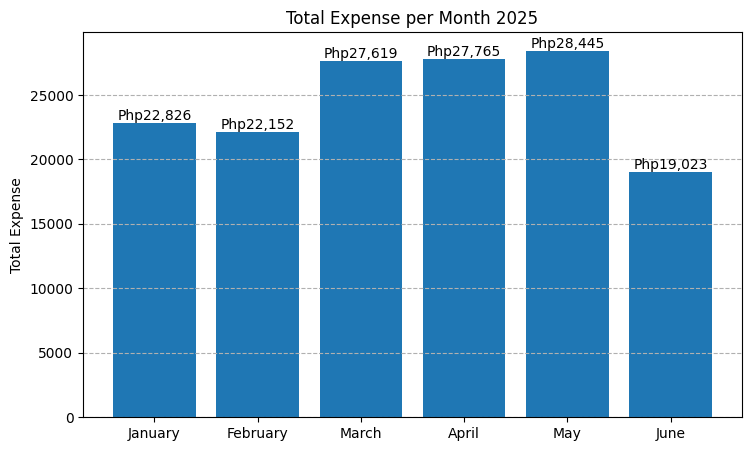

In [118]:
plt.figure(figsize=(8.5,5))
plt.grid(axis='y', linestyle='--', alpha=1)

bars = plt.bar(months_, list(monthly_exp.values()))
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'Php{height:,.0f}', 
             ha='center', va='bottom', fontsize= 10)
plt.title('Total Expense per Month 2025')
plt.ylabel('Total Expense')